In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
)
from sklearnex import patch_sklearn 

# Patch da Intel para otimizar o SVM para CPUs Intel
patch_sklearn()

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
# --- Carregamento e reparticao dos dados em treinamento, validacao e teste ---
# Caminhos
processed_path = '../../data/processed/synthetic_dataset'
train_path = os.path.join(processed_path, 'train_processed.npz')
test_path = os.path.join(processed_path, 'test_processed.npz')

# Carregar dados
train_data = np.load(train_path)
test_data = np.load(test_path)

X_full = np.vstack((train_data['X'], test_data['X']))
y_full = np.concatenate((train_data['y'], test_data['y']))

print("Dados carregados:")
print(f"X: {X_full.shape}, y: {y_full.shape}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, random_state=42, stratify=y_temp
)

print("Proporção dos conjuntos:")
print(f"Treino: {X_train.shape}, Validação: {X_val.shape}, Teste: {X_test.shape}")

Dados carregados:
X: (10000, 13962), y: (10000,)
Proporção dos conjuntos:
Treino: (7000, 13962), Validação: (1000, 13962), Teste: (2000, 13962)


In [10]:
# --- Treinamento do SVM ---
# SVM com kernel RBF e probabilidade ativada
svm_model = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, class_weight='balanced', random_state=42)

print("Treinando o modelo SVM...")
start = time.time()
svm_model.fit(X_train, y_train)
print(f"Treinamento concluído em {time.time() - start:.2f}s")

Treinando o modelo SVM...
Treinamento concluído em 3.44s


Melhor limiar (threshold): 0.0018
F1-Score correspondente: 0.1085
PR AUC (val): 0.0708 | ROC AUC (val): 0.5067


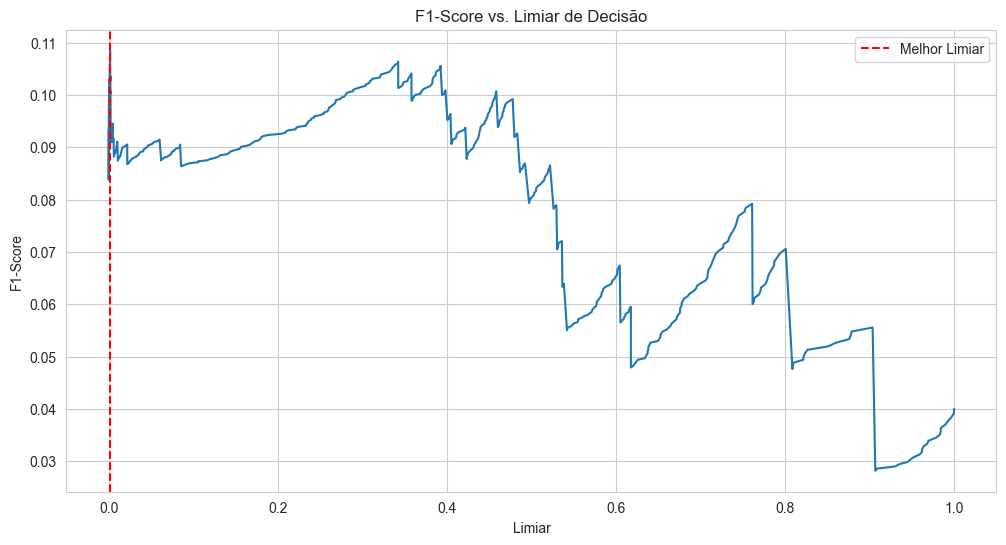

In [11]:
# --- Avaliacao no coinjunto de validacao ---
y_val_probs = svm_model.predict_proba(X_val)[:, 1]

# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_val, y_val_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Melhor limiar (threshold): {best_threshold:.4f}")
print(f"F1-Score correspondente: {f1_scores[best_idx]:.4f}")

# PR AUC e ROC AUC
pr_auc_val = auc(recall, precision)
roc_auc_val = roc_auc_score(y_val, y_val_probs)
print(f"PR AUC (val): {pr_auc_val:.4f} | ROC AUC (val): {roc_auc_val:.4f}")

# Curva F1
plt.plot(thresholds, f1_scores[:-1])
plt.axvline(best_threshold, color='r', linestyle='--', label='Melhor Limiar')
plt.title('F1-Score vs. Limiar de Decisão')
plt.xlabel("Limiar")
plt.ylabel("F1-Score")
plt.legend()
plt.show()

--- Relatório de Classificação (Teste) ---
              precision    recall  f1-score   support

      Normal       0.95      0.46      0.62      1902
    Anomalia       0.05      0.53      0.09        98

    accuracy                           0.46      2000
   macro avg       0.50      0.49      0.35      2000
weighted avg       0.91      0.46      0.59      2000



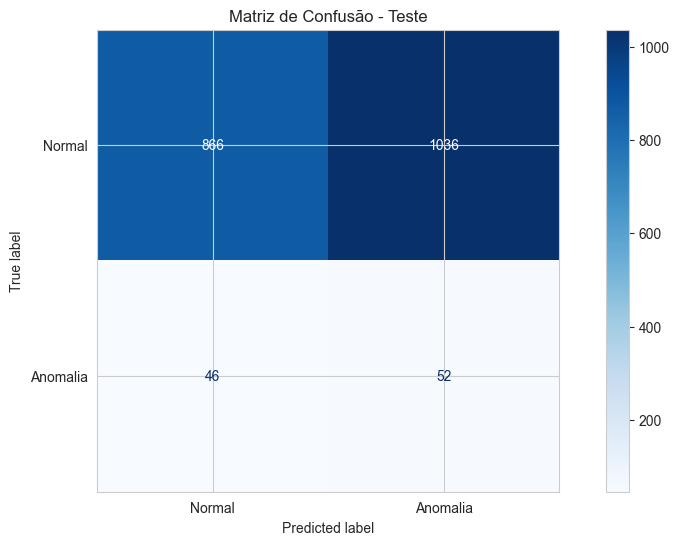

--- Métricas AUC ---
ROC AUC (teste): 0.4997
PR AUC (teste): 0.0514


In [12]:
y_test_probs = svm_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_threshold).astype(int)

print("--- Relatório de Classificação (Teste) ---")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Anomalia']))

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomalia'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - Teste")
plt.show()

# AUCs
print("--- Métricas AUC ---")
print(f"ROC AUC (teste): {roc_auc_score(y_test, y_test_probs):.4f}")
precision_t, recall_t, _ = precision_recall_curve(y_test, y_test_probs)
print(f"PR AUC (teste): {auc(recall_t, precision_t):.4f}")